# Defining Repetitive "Objects"

In the previous notebook, we determined that using `ASSET_ID`s attached to each work task was insufficient for our definition of "repetitive tasks." This was due to the fact assets were rarely attached to corrective tasks in the provided datasets. In an ideal world, we would use the assets tied to each work task to identify if any tickets reference the same problem; however, since asset data is not reliable, we will need to take a different heuristic approach.

In this notebook, we take an alternative approach to defining what constitutes a repetitive task. Rather than using the entire dataset, we condense the data to include only work tasks that have space numbers attached (around half of the original dataset), and use other attributes of the work tasks as a proxy for whether it references the same problem as a recently submitted one. 

### Our New Definition: 'Objects'
Rather than tying tasks to their 'Assets' to determine if they reference the same problem, we define 'objects' to represent a combination of work task features that will be highly correlated among tasks that describe the same issue. Two tickets describe the same object if both tickets share the same: 
1. Service class,
2. Request class,
3. Building,
4. Space (describes room or area inside the building; e.g. "431", "106A", or "HALL-B")

**In this formulation, a task will be defined as "repetitive" if another corrective task referencing the same object occurs within 90 days.** 

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../utils'))

import pandas as pd
import numpy as np
from data_aggregation_tools import merge_tickets_assets, convert_cols_to_datetime

# Set dataframes to display all columns
pd.set_option('display.max_columns', None)

df_tickets = pd.read_csv("../../data/V_OM_WORK_TASK.csv")
df_assets = pd.read_csv("../../data/V_OM_WORK_TASK_ASSET.csv")

# Generate merged tickets / assets file
df_tickets_assets = merge_tickets_assets(df_tickets=df_tickets, df_assets=df_assets)
df_tickets_assets = convert_cols_to_datetime(df_tickets_assets)

print(f"shape of df_tickets: {df_tickets.shape}")
print(f"shape of df_assets: {df_assets.shape}")
print(f"shape of df_tickets_assets: {df_tickets_assets.shape}")

# print(df_tickets_assets["CREATE_DATE_LTZ"].dtype) # <-- should return 'datetime64[ns]'
# df_tickets_assets.head()

/var/folders/y2/tsyh3wpj3mj7zcv4hfd0knl40000gn/T/ipykernel_50221/2664763239.py:12: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tickets = pd.read_csv("../../data/V_OM_WORK_TASK.csv")
/var/folders/y2/tsyh3wpj3mj7zcv4hfd0knl40000gn/T/ipykernel_50221/2664763239.py:13: DtypeWarning: Columns (0,3,4,5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_assets = pd.read_csv("../../data/V_OM_WORK_TASK_ASSET.csv")


shape of df_tickets: (227205, 47)
shape of df_assets: (316257, 9)
shape of df_tickets_assets: (316257, 55)


In [2]:
# Compare how many tickets have spaces attached vs. don't
print(f"Number of rows with room number attached: {len(df_tickets_assets)}") 
df_tickets_assets_spaces = df_tickets_assets.dropna(subset=['SPACE'])
print(f"Number of rows with room number attached: {len(df_tickets_assets_spaces)}")

# Show first 20 rows (notice how all tasks have 'SPACE' values)
df_tickets_assets_spaces.head(20)

Number of rows with room number attached: 316257
Number of rows with room number attached: 125227


,WORK_TASK_ID,WORK_TASK_NAME_ticket,WORK_TASK_STATUS_ticket,RICE_WORK_STATUS,ASSIGNMENT_STATUS,DESCRIPTION,TASK_TYPE,TASK_PRIORITY,REQUEST_CLASS,SERVICE_CLASS,PRIMARY_LOCATION,PROPERTY,BUILDING,FLOOR,SPACE,GEOGRAPHY_LOOKUP,CUSTOMER_ORGANIZATION,CUSTOMER_COMPANY,CUSTOMER_DIVISION,CUSTOMER_DEPARTMENT,RESPONSIBLE_ORGANIZATION_NAME,ORGANIZATION_TYPE,RESPONSIBLE_ORGANIZATION_PATH,RESPONSIBLE_PERSON_NAME,RESPONSIBLE_PERSON_EMAIL,RESPONSIBLE_PERSON_WORKPHONE,BASELINE_START_LTZ,BASELINE_END_LTZ,ASSIGNED_DATE_LTZ,PLANNED_START_LTZ,PLANNED_END_LTZ,PLANNED_FOLLOW_UP_DATE_LTZ,PLANNED_WORKING_DAYS,PLANNED_COST,ACTUAL_START_LTZ,ACTUAL_END_LTZ,RICE_ACTUAL_COST,REVERSAL,BILLING_TYPE,ACCOUNTING_HOLD,ACCOUNTING_HOLD_REASON,COA_ACCOUNT_STRING,POETAF_ACCOUNT_STRING,NUMBER_OF_ASSETS,RESOLUTION_DESCRIPTION,CAPITAL_PROJECT_ID,CREATE_DATE_LTZ,WORK_TASK_NAME_asset,WORK_TASK_STATUS_asset,ASSET_ID,ASSET_NAME,ASSET_STATUS,ASSET_PRIMARY_LOCATION,ASSET_PRIMARY_LOCATION_BUILDING,ACCOUNT_STRING
0,1302351,RICE - DEFAULT - Work Task Template - Correcti...,Completed,Work Done,Completed,student at Jones North room 129 has hand foot ...,Corrective,3 - Routine,Custodial Issues,Custodial,\Locations\Rice\Mary Gibbs Jones College - Nor...,Rice,Mary Gibbs Jones College - North,01,129,\Geography\North America\United States\Texas\H...,\Organizations\Rice\Dean of Undergraduates\Stu...,Rice,Dean of Undergraduates,Student Health Services,HD Custodial,Workgroup,\Organizations\DEFAULT Workgroup (for Default ...,Melissa Salinas,melissasalinas@rice.edu,713-348-8264,2025-09-19 08:24:42,2025-10-10 08:24:42,2025-09-19 08:24:45,2025-09-19 08:24:42,2025-10-10 08:24:42,2025-09-21 08:24:42,21,NaN,2025-09-19 08:24:42,2025-09-22 10:36:51,0.0,False,Billable,No,NaN,"10,84100,103,030000,8985,800,9999,9999,999,999",NaN,0,NaN,NaN,2025-09-19 08:24:42,RICE - DEFAULT - Work Task Template - Correcti...,Completed,NaN,NaN,NaN,NaN,NaN,NaN
10,1302360,RICE - DEFAULT - Work Task Template - Correcti...,Completed,Work Done,Completed,Replace lamps rm 860J Contact Center : Juan Ro...,Corrective,3 - Routine,Other Electrical Issues,Electrical,\Locations\Rice\Bioscience Research Collaborat...,Rice,Bioscience Research Collaborative,02,206,\Geography\North America\United States\Texas\H...,\Organizations\Rice\Real Estate and Facilities...,Rice,Real Estate and Facilities and Capital Planning,BRC - Management Office,18 Controls,Workgroup,\Organizations\DEFAULT Workgroup (for Default ...,Milton Baines,Milton.L.Baines@rice.edu,NaN,2025-09-19 08:41:17,2025-10-10 08:41:17,2025-09-19 08:41:21,2025-09-19 08:41:17,2025-10-10 08:41:17,2025-09-21 08:41:17,21,NaN,2025-09-19 08:42:43,2025-10-31 07:29:22,0.0,False,Billable,No,NaN,"10,87001,100,000000,8985,500,9999,9999,999,999",NaN,0,NaN,NaN,2025-09-19 08:41:17,RICE - DEFAULT - Work Task Template - Correcti...,Completed,NaN,NaN,NaN,NaN,NaN,NaN
11,1302362,RICE - DEFAULT - Work Task Template - Correcti...,Completed,Work Done,Completed,Replace ceiling tile rm 870 Contact Center : J...,Corrective,3 - Routine,Other Carpentry,Carpentry,\Locations\Rice\Bioscience Research Collaborat...,Rice,Bioscience Research Collaborative,02,206,\Geography\North America\United States\Texas\H...,\Organizations\Rice\Real Estate and Facilities...,Rice,Real Estate and Facilities and Capital Planning,BRC - Management Office,18 Controls,Workgroup,\Organizations\DEFAULT Workgroup (for Default ...,Milton Baines,Milton.L.Baines@rice.edu,NaN,2025-09-19 08:44:17,2025-10-10 08:44:17,2025-09-19 08:44:21,2025-09-19 08:44:17,2025-10-10 08:44:17,2025-09-21 08:44:17,21,NaN,2025-09-19 08:44:57,2025-09-29 09:50:08,0.0,False,Non-Billable,No,NaN,"10,87001,100,000000,8985,500,9999,9999,999,999",NaN,0,Replaced stained stained tiles.,NaN,2025-09-19 08:44:17,RICE - DEFAULT - Work Task Template - Correcti...,Completed,NaN,NaN,NaN,NaN,NaN,NaN
12,1302363,RICE - DEFAULT - Work Task Template - Correcti...,Completed,Work Done,Completed,"Toilet doesn’t flush again :,)",Corrective,2 - Urgent,Toilet/Urinal,Plumbing,\Locations\Ri

## Rules for individual "object"

Here, we test some groupings to define an 'object,' the identifier we will implement for defining repetitive tasks. The groupings (tickets with the same groupings are defined as referencing the same 'object') we experimented with are as follows:

Grouping 1:
1. Same service class
2. Same request class
3. Same building 

Grouping 2: 
1. Same service class
2. Same request class
3. Same building
4. Same responsible organization name

Grouping 3: 
1. Same service class
2. Same request class
3. Same building
4. Same responsible organization name
5. Same floor

Grouping 4: 
1. Same service class
2. Same building
3. Same floor
4. Same space

We expect grouping 4 to be the most accurate and flag the fewest number of 'repetitive tasks.' This is because the other groupings do not have as granular of a spatial resolution, as they do not include the `SPACE` field. Still, we want to compare all of them to quantify the improvement that grouping with the `SPACE` field offers.

**Future idea:**
Once our keyword detection software is more complete, we may try identifying similar tasks by enforcing a ratio of similar keywords in the `'DESCRIPTION'` field. This field includes user-written textual descriptions of the issue the work task should aim to fix. We could also use keywords in the description to verify that 'objects' reference the *same problems in each space*, rather than just the same space in general. We expect this will be the case, since we are also grouping by service class. 

**If the same "object," as defined above, has multiple work tasks in the same 90-day window, then we flag it as a possible persistent issue (repetitive task).**

In [3]:
from repetitive_tasks import detect_repetitive_objects

# Group by "Object"

group_cols_tests_dict = {
    'grouping_1': ['SERVICE_CLASS', 'REQUEST_CLASS', 'BUILDING'],
    'grouping_2': ['SERVICE_CLASS', 'REQUEST_CLASS', 'BUILDING', 'RESPONSIBLE_ORGANIZATION_NAME'],
    'grouping_3': ['SERVICE_CLASS', 'REQUEST_CLASS', 'BUILDING', 'RESPONSIBLE_ORGANIZATION_NAME', 'FLOOR'],
    'grouping_4': ['SERVICE_CLASS', 'BUILDING', 'FLOOR', 'SPACE']
}

# Define number of days between tasks for flagging as repetitive
num_days = 90

# Filter the tickets by "object" (as defined above by tickets with the same group_cols)
for grouping_name, group_cols in group_cols_tests_dict.items():
    df_tickets_filtered_by_object, object_repetitive_dict, all_objects_dict = detect_repetitive_objects(df_tickets_assets_spaces, group_cols, num_days, verbose=True)
    
    # Print results
    print(f"[{grouping_name}] {group_cols} → Found {len(df_tickets_filtered_by_object)} repetitive tasks within {num_days} days.\n")


90 days 00:00:00
Number of columns pre-corrective: 125227
Number of corrective tasks: 69004
Number of unique objects (groups): 11085
Found 41690 repetitive tasks by object within 90 days.
[grouping_1] ['SERVICE_CLASS', 'REQUEST_CLASS', 'BUILDING'] → Found 41690 repetitive tasks within 90 days.

90 days 00:00:00
Number of columns pre-corrective: 125227
Number of corrective tasks: 69004
Number of unique objects (groups): 13475
Found 39772 repetitive tasks by object within 90 days.
[grouping_2] ['SERVICE_CLASS', 'REQUEST_CLASS', 'BUILDING', 'RESPONSIBLE_ORGANIZATION_NAME'] → Found 39772 repetitive tasks within 90 days.

90 days 00:00:00
Number of columns pre-corrective: 125227
Number of corrective tasks: 69004
Number of unique objects (groups): 21767
Found 28332 repetitive tasks by object within 90 days.
[grouping_3] ['SERVICE_CLASS', 'REQUEST_CLASS', 'BUILDING', 'RESPONSIBLE_ORGANIZATION_NAME', 'FLOOR'] → Found 28332 repetitive tasks within 90 days.

90 days 00:00:00
Number of columns pr

## Results from Groupings

| Grouping | Unique 'Objects' | Repetitive Tasks (90 days) | 'Objects' to Repetitive Tasks Ratio |
|----------|--------------|---------------------------|-----------------------------------|
| Grouping 1 | 11,085 | 41,690 | 0.2659 |
| Grouping 2 | 13,475 | 39,772 | 0.3388 |
| Grouping 3 | 21,767 | 28,332 | 0.7683 |
| Grouping 4 | 29,222 | 14,684 | 1.9906 |

The output above strongly suggests that grouping 4 is the most optimal for detecting truly repetitive tasks. This is because it creates more unique objects per repetitive task observed ('objects' to repetitive tasks ratio).

For the rest of this analysis, we will group using Grouping 4, which includes the room/space the task has been called to, as well as its service class, which classifies the work request into broad categories (such as custodial, electrical, plumbing, HVAC, etc.).

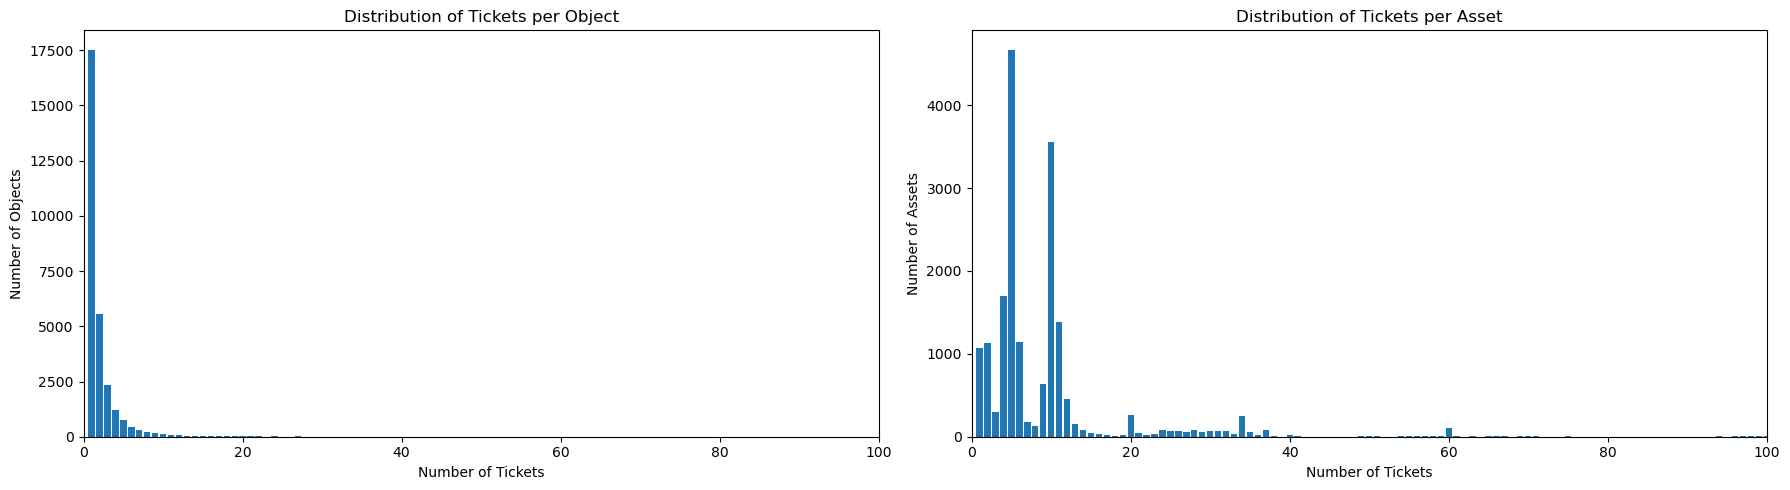

Total Tickets per Object,Number of Objects with that count
1,17522
2,5537
3,2362
4,1215
5,778
6,425
7,310
8,215
9,162
10,118


In [4]:
import matplotlib.pyplot as plt

# Count tickets per object using object_dict
tickets_per_object = pd.Series(all_objects_dict).value_counts().sort_index()
tickets_per_asset = df_tickets_assets.groupby('ASSET_ID').size().value_counts().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

# Object plot
ax1.bar(tickets_per_object.index, tickets_per_object.values)
ax1.set_xlabel('Number of Tickets')
ax1.set_ylabel('Number of Objects')
ax1.set_title('Distribution of Tickets per Object')

# Asset plot
ax2.bar(tickets_per_asset.index, tickets_per_asset.values)
ax2.set_xlabel('Number of Tickets')
ax2.set_ylabel('Number of Assets')
ax2.set_title('Distribution of Tickets per Asset')

# Limit to 0-100 tickets; only show anomalies (>100 tickets) in the table below graphs
ax1.set_xlim(0, 100)
ax2.set_xlim(0, 100)

plt.tight_layout()
plt.show()

# Tables side by side
df_summary_object = pd.DataFrame({
    'Total Tickets per Object': tickets_per_object.index,
    'Number of Objects with that count': tickets_per_object.values
}).reset_index(drop=True)

df_summary_asset = pd.DataFrame({
    'Total Tickets per Asset': tickets_per_asset.index,
    'Number of Assets with that count': tickets_per_asset.values
}).reset_index(drop=True)

from IPython.display import display, HTML
display(HTML(
    '<div style="display: flex; gap: 50px;">'
    + df_summary_object.style.hide(axis='index').to_html()
    + df_summary_asset.style.hide(axis='index').to_html()
    + '</div>'
))


## Discussion: Objects vs Asset ID

In the bar graphs & tables above, you can see the distributions of "repetitive tickets" when using two methodologies. **On the left,** you can see the result of defining repetitive tasks in terms of 'objects' called within 90 days. **On the right,** our 'object' proxy is replaced with our old methodology which used `'ASSET_ID'`, which we determined in `repetitive_assets.ipynb` to be *insufficient* for identifying repeated tasks.

The distribution on the left (using objects) is much cleaner and appears to be exponential, while the distribution on the right is extremely noisy and hard to define. ***This is a good sign!*** It's an indication that we are on the right track, and our objects are well-defined.

*Note that the x-axes are cut of at 100 tickets even though there are some anomalies which have >100 tickets attached to them. This choice was made for better visualization, and the anomalies can be seen in the tables below the bar charts.*

Let's do the same thing for the number of 'repetitive tasks.' We will experiment by visualizing the number of repetitive tasks per unique 'object' vs. the number of repetitive tasks using unique 'assets.' 

Max days between 'repetitive tasks': 90 days 00:00:00


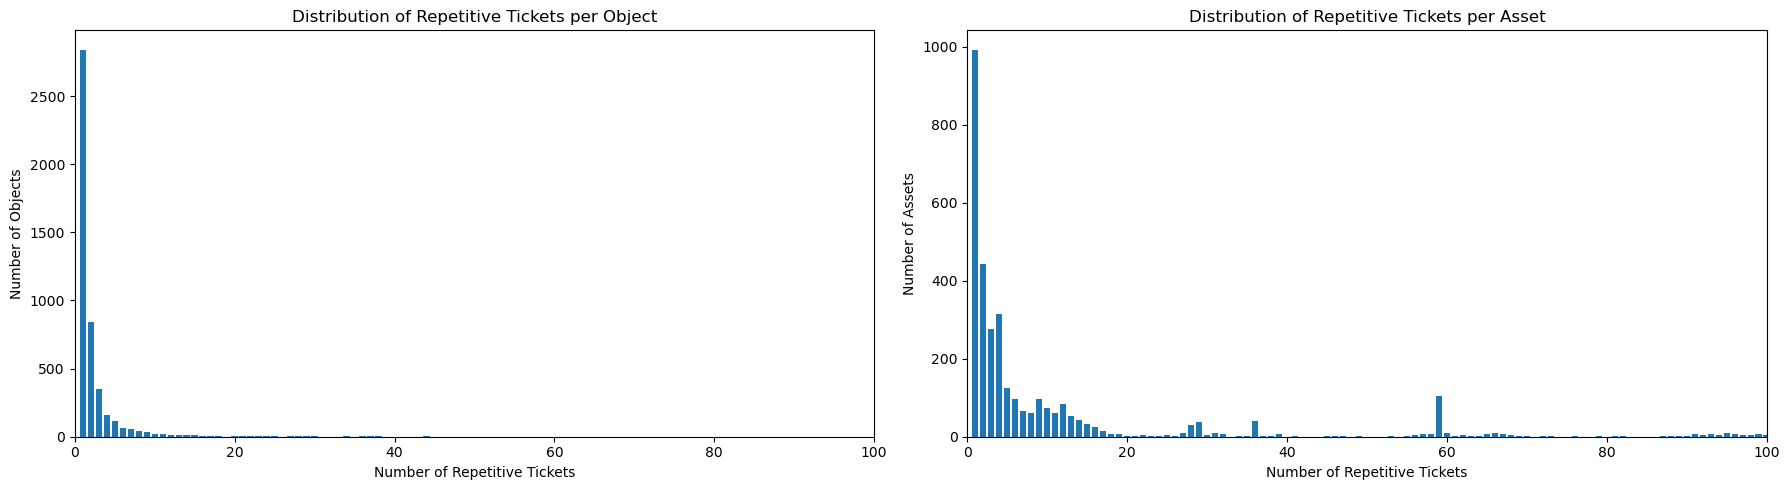

Repetitive Tickets per Object,Number of Objects with that count
1,2841
2,840
3,353
4,162
5,118
6,63
7,54
8,43
9,34
10,21


In [5]:
# --------------------------------------------------------------------------------
# | Code from `repetitive_assets.ipynb` to generate repetitive tasks by ASSET_ID |
# --------------------------------------------------------------------------------

# Sort the DataFrame by ASSET_ID and BASELINE_START_LTZ for efficient processing
df_merged_assets_sorted = df_tickets_assets.sort_values(by=['ASSET_ID', 'BASELINE_START_LTZ']).reset_index(drop=True)

repeated_tasks_by_asset_list = []
num_days = pd.Timedelta(days=90) 

print(f"Max days between 'repetitive tasks': {num_days}")

# Group by ASSET_ID
for asset_id, group in df_merged_assets_sorted.groupby('ASSET_ID'):
    # Iterate through each task in the group
    for i in range(len(group)):
        current_task = group.iloc[i]
        current_task_time = current_task['BASELINE_START_LTZ']

        # Check subsequent tasks for repetition within 90 days
        # Start checking from the next task (i+1) within the same asset group
        subsequent_tasks = group.iloc[i+1:]
        for j in range(len(subsequent_tasks)):
            other_task = subsequent_tasks.iloc[j]
            other_task_time = other_task['BASELINE_START_LTZ']

            time_difference = other_task_time - current_task_time

            if pd.isna(time_difference): # Skip if time_difference is NaT
                continue

            if time_difference <= num_days:
                # If a subsequent task is found within 90 days, the current task is repetitive
                repeated_tasks_by_asset_list.append(current_task.to_dict())
                break  # Move to the next current_task, as this one is identified as repetitive
            elif time_difference > num_days:
                # Since tasks are sorted by time, if the current subsequent task is already
                # beyond 90 days, all further tasks will also be, so we can break early.
                break

# Create a new DataFrame from the identified repeated tasks
df_tickets_filtered_by_asset = pd.DataFrame(repeated_tasks_by_asset_list)

# Count tickets per object using object_dict
repetitive_per_object = pd.Series({k: len(v) for k, v in object_repetitive_dict.items()}).value_counts().sort_index()
repetitive_per_asset = df_tickets_filtered_by_asset['ASSET_ID'].value_counts().value_counts().sort_index()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

# Object plot
ax1.bar(repetitive_per_object.index, repetitive_per_object.values)
ax1.set_xlabel('Number of Repetitive Tickets')
ax1.set_ylabel('Number of Objects')
ax1.set_title('Distribution of Repetitive Tickets per Object')

# Asset plot
ax2.bar(repetitive_per_asset.index, repetitive_per_asset.values)
ax2.set_xlabel('Number of Repetitive Tickets')
ax2.set_ylabel('Number of Assets')
ax2.set_title('Distribution of Repetitive Tickets per Asset')

# Limit to 0-100 tickets; only show anomalies (>100 tickets) in the table below graphs
ax1.set_xlim(0, 100)
ax2.set_xlim(0, 100)

plt.tight_layout()
plt.show()

# Tables side by side
df_summary_object = pd.DataFrame({
    'Repetitive Tickets per Object': repetitive_per_object.index,
    'Number of Objects with that count': repetitive_per_object.values
}).reset_index(drop=True)

df_summary_asset = pd.DataFrame({
    'Repetitive Tickets per Asset': repetitive_per_asset.index,
    'Number of Assets with that count': repetitive_per_asset.values
}).reset_index(drop=True)

from IPython.display import display, HTML
display(HTML(
    '<div style="display: flex; gap: 50px;">'
    + df_summary_object.style.hide(axis='index').to_html()
    + df_summary_asset.style.hide(axis='index').to_html()
    + '</div>'
))


**Great, the distribution on the left (using 'objects') looks much cleaner than the one on the right (using 'assets')!** 

### For the distribution using 'objects' (left side):
1. There are some objects that are chronically failing (tail of the distribution), but most assets have only failed repetitively once or twice. 
2. The distribution is almost monotonically decreasing, which is what we would expect (fewer objects should have high repetition counts)

### For the distribution using 'assets' (right side):
1. There are a high number of assets that appear to be chronically failing; the tail end of the distribution is much taller than expected.
2. There are a high number of assets that have been detected as repetitive 59 times, which is very unexpected and abnormal

Now, we can do some deeper analysis on repetitive objects, and prepare them for our isolation forest model. 